<a href="https://colab.research.google.com/github/FaizWorks21/SugarcaneLeafClassification/blob/main/Sugarcane_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
os.listdir("/content")

['.config',
 '.ipynb_checkpoints',
 'Sugarcane_Disease_Detection.zip',
 'Sugarcane_Disease_Detection.ipynb.zip',
 'sample_data']

In [ ]:
import zipfile

zip_path = "/content/Sugarcane_Disease_Detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os

dataset_path = "/content/dataset"

for folder in os.listdir(dataset_path):
    print(folder)

RedRot
Mosaic
Healthy
Yellow
Rust


In [ ]:
import tensorflow as tf

img_size = (224,224)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2521 files belonging to 5 classes.
Using 2017 files for training.
Found 2521 files belonging to 5 classes.
Using 504 files for validation.


In [ ]:
class_names = train_dataset.class_names
print("Classes:", class_names)

Classes: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']


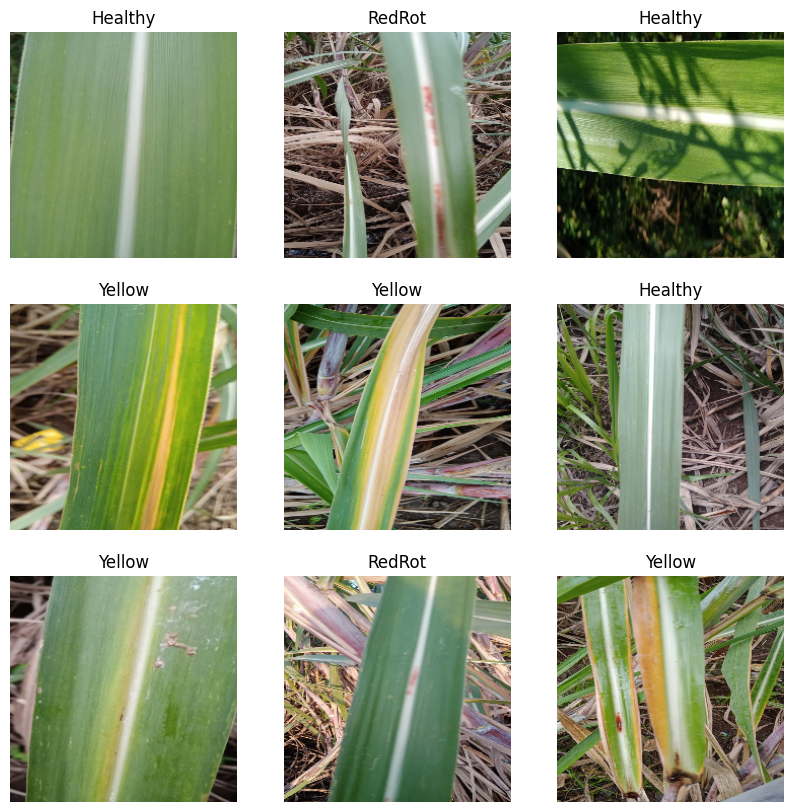

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
model = tf.keras.Sequential([

tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Flatten(),

tf.keras.layers.Dense(128,activation='relu'),

tf.keras.layers.Dense(len(class_names),activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
train_dataset,
validation_data=val_dataset,
epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - accuracy: 0.2965 - loss: 2.0286 - val_accuracy: 0.4167 - val_loss: 1.3968
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5323 - loss: 1.1513 - val_accuracy: 0.5675 - val_loss: 1.0682
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6738 - loss: 0.8511 - val_accuracy: 0.6726 - val_loss: 0.8562
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7461 - loss: 0.7157 - val_accuracy: 0.7083 - val_loss: 0.7743
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8029 - loss: 0.5261 - val_accuracy: 0.7560 - val_loss: 0.7300
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8925 - loss: 0.3208 - val_accuracy: 0.7817 - val_loss: 0.7793
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9132 - loss: 0.2558 - val_accuracy: 0.7440 - val_loss: 0.8971
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9567 - loss: 0.1452 - val_accuracy: 0.7619 -

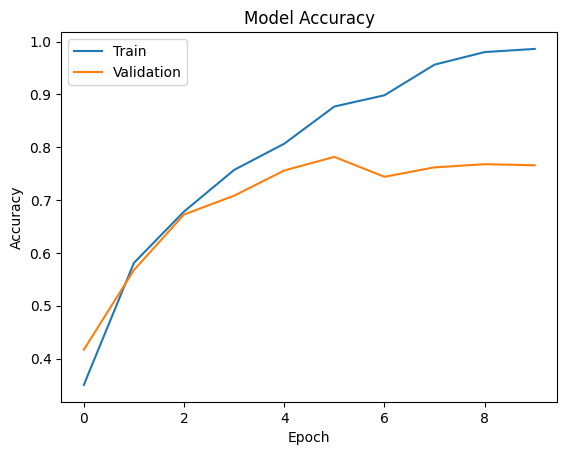

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
model.save("sugarcane_disease_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: RedRot


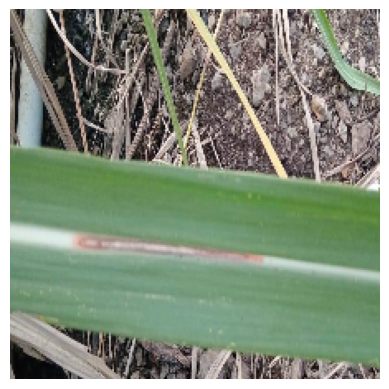

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img("/content/redrot (10).jpeg", target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

print("Prediction:", class_names[np.argmax(prediction)])